Поскольку исходники датасетов с моей работы находятся под NDA данный EDA проведён на синтетических данных и не является источником инсайдерской информации.



**Выводы по реальным данным:Выводы на основании реальных данных - в отличие от синтетики качество данных в ряде показателей не является удовлетворительным, уточнение ряда булевых признаков при их расхождении, точная классификация ролей и обоснованность алгоритмически выевляемых расхождений требует анализа введённого людьми текста.Классификация ряда применяющихся типов не очевидна, часто имеются синонимичные по общему смыслу типы с разными классами в системе. Консультация с доступными экспертами ситуацию не прояснил - типы сложились в ходе особенностей практического применения. В ряде процедур отсутствует однозначная связь между конкретной заявкой и итоговым документом, что требует анализа текста 1-4 заявок.Часто в разных системах для обозначения одного и того же используются разные варинты написания, что усложняет сверку алгоритмами, однако при помощи алгоритмических методов можно значительно сократить колличество анализируемых строк (в конкретном примере ппереписанных в процессе условий получилось снизить колличество случаев с тысяч до около двух сотен)**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


contracts = pd.read_csv(pth+'contracts.csv', parse_dates=['дата_создания', 'дата_подписания', 'дата_исполнения', 'дата_расторжения'])
counterparties = pd.read_csv(pth+'counterparties.csv', parse_dates=['дата_регистрации'])
items = pd.read_csv(pth+'contract_items.csv')
payments = pd.read_csv(pth+'payment_history.csv', parse_dates=['дата_выплаты'])
approvals = pd.read_csv(pth+'approvals.csv', parse_dates=['дата_согласования'])
acts = pd.read_csv(pth+'acceptance_acts.csv', parse_dates=['дата_акта'])
disputes = pd.read_csv(pth+'disputes.csv', parse_dates=['дата_возникновения', 'дата_решения'])
restrictions = pd.read_csv(pth+'contract_restrictions.csv', parse_dates=['дата_начала', 'дата_окончания'])

print("Contracts shape:", contracts.shape)
contracts.info()

Contracts shape: (6437, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 33 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   id_договора                          6437 non-null   int64         
 1   вид_договора                         6437 non-null   object        
 2   наименование                         6437 non-null   object        
 3   сумма                                6437 non-null   float64       
 4   валюта                               6437 non-null   object        
 5   сумма_в_рублях                       6437 non-null   float64       
 6   ставка_ндс                           6437 non-null   int64         
 7   тип_цены                             6437 non-null   object        
 8   дата_создания                        6437 non-null   datetime64[ns]
 9   дата_подписания                      5760 non-null   date

In [44]:
contracts.describe(include='all')

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,id_договора,вид_договора,наименование,сумма,валюта,сумма_в_рублях,ставка_ндс,тип_цены,дата_создания,дата_подписания,...,условия_оплаты,ответственность_сторон,форс_мажор,порядок_разрешения_споров,конфиденциальность,применимое_право,срок_уведомления_о_расторжении_дней,гарантийный_срок_мес,наличие_лицензий_у_контрагента,архивный
count,6437.000000,6437,6437,6.437000e+03,6437,6.437000e+03,6437.000000,6437,6437,5760,...,6437,6437,6437,6437,6437,6437,6437.000000,6437.000000,6437,6437
unique,NaN,5,6437,NaN,6,NaN,NaN,2,NaN,NaN,...,5,4,2,3,2,4,NaN,NaN,2,2
top,NaN,Поставка,Аренда №1 от 07.08.2024,NaN,RUB,NaN,NaN,С НДС,NaN,NaN,...,100% предоплата,Штраф 10% от суммы,Да,Суд по месту нахождения ответчика,Нет,КНР,NaN,NaN,True,True
freq,NaN,1353,1,NaN,4020,NaN,NaN,5152,NaN,NaN,...,1307,1631,3235,2166,3246,1655,NaN,NaN,3226,3245
mean,3219.000000,NaN,NaN,4.914401e+06,NaN,3.645646e+07,15.055150,NaN,2024-08-24 14:09:51.704210176,2024-09-06 07:39:29.999999744,...,NaN,NaN,NaN,NaN,NaN,NaN,50.311791,7.432034,NaN,NaN
min,1.000000,NaN,NaN,1.699410e+03,NaN,6.458000e+01,0.000000,NaN,2023-02-28 00:00:00,2023-03-02 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,0.000000,NaN,NaN
25%,1610.000000,NaN,NaN,2.455364e+06,NaN,9.904370e+05,10.000000,NaN,2023-11-25 00:00:00,2023-12-06 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,0.000000,NaN,NaN
50%,3219.000000,NaN,NaN,4.840494e+06,NaN,4.642133e+06,20.000000,NaN,2024-08-22 00:00:00,2024-09-02 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,50.000000,0.000000,NaN,NaN
75%,4828.000000,NaN,NaN,7.383226e+06,NaN,8.568522e+06,20.000000,NaN,2025-05-25 00:00:00,2025-06-06 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,71.000000,14.000000,NaN,NaN
max,6437.000000,NaN,NaN,9.999688e+06,NaN,9.641377e+08,20.000000,NaN,2026-02-27 00:00:00,2026-03-28 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,90.000000,36.000000,NaN,NaN


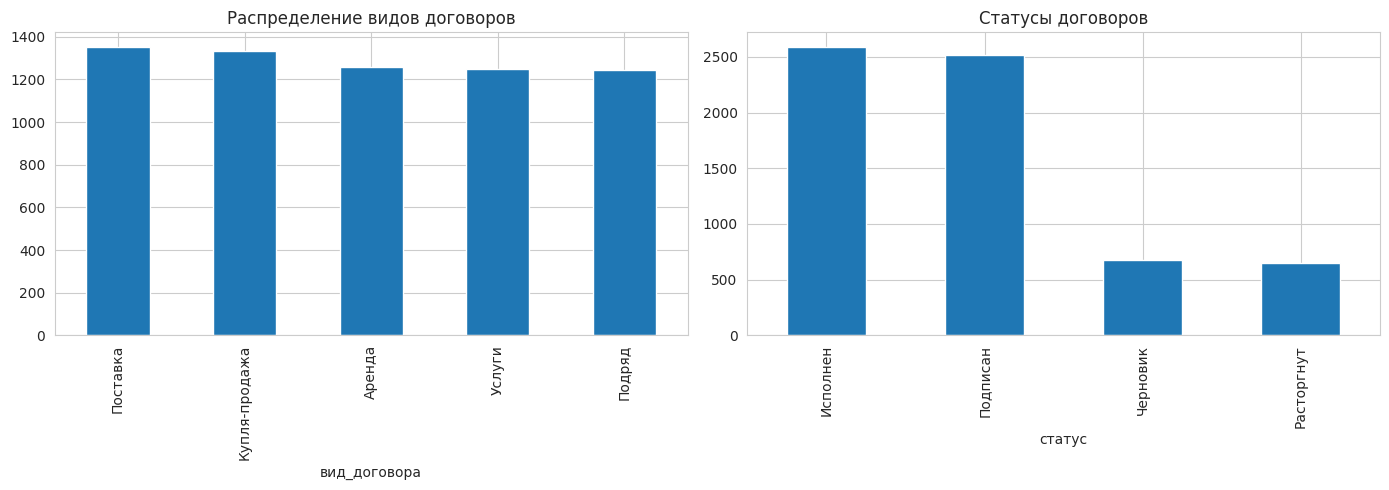

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
contracts['вид_договора'].value_counts().plot(kind='bar', ax=axes[0], title='Распределение видов договоров')
contracts['статус'].value_counts().plot(kind='bar', ax=axes[1], title='Статусы договоров')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


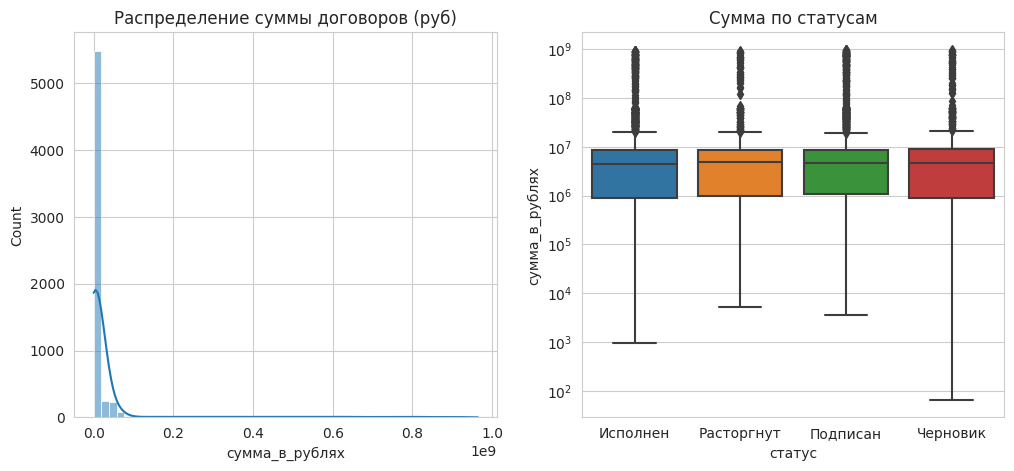

In [46]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(contracts['сумма_в_рублях'], bins=50, kde=True)
plt.title('Распределение суммы договоров (руб)')
plt.subplot(1,2,2)
sns.boxplot(x='статус', y='сумма_в_рублях', data=contracts)
plt.title('Сумма по статусам')
plt.yscale('log')
plt.show()

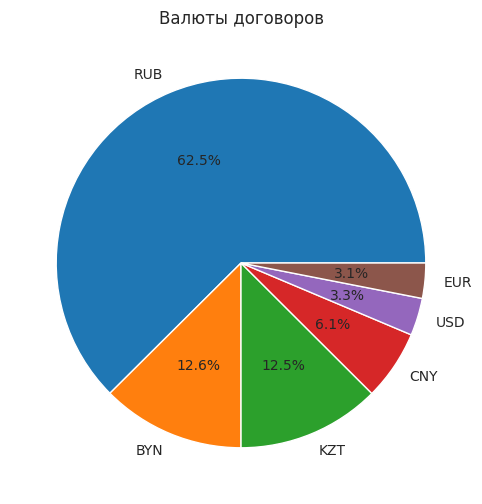

In [47]:
contracts['валюта'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Валюты договоров')
plt.ylabel('')
plt.show()

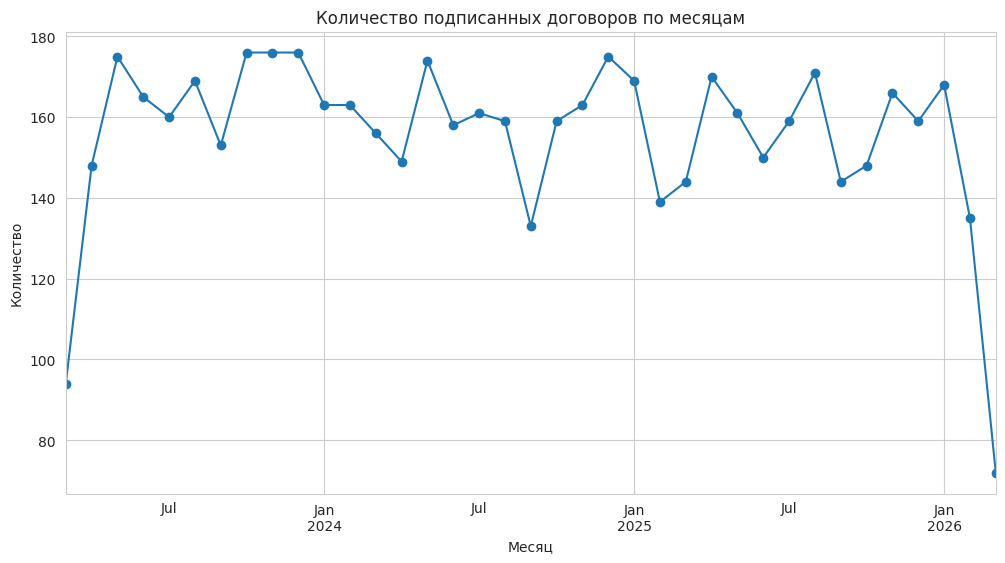

In [48]:
contracts['месяц_подписания'] = contracts['дата_подписания'].dt.to_period('M')
monthly = contracts[contracts['статус']!='Черновик'].groupby('месяц_подписания').size()
monthly.plot(kind='line', marker='o', title='Количество подписанных договоров по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


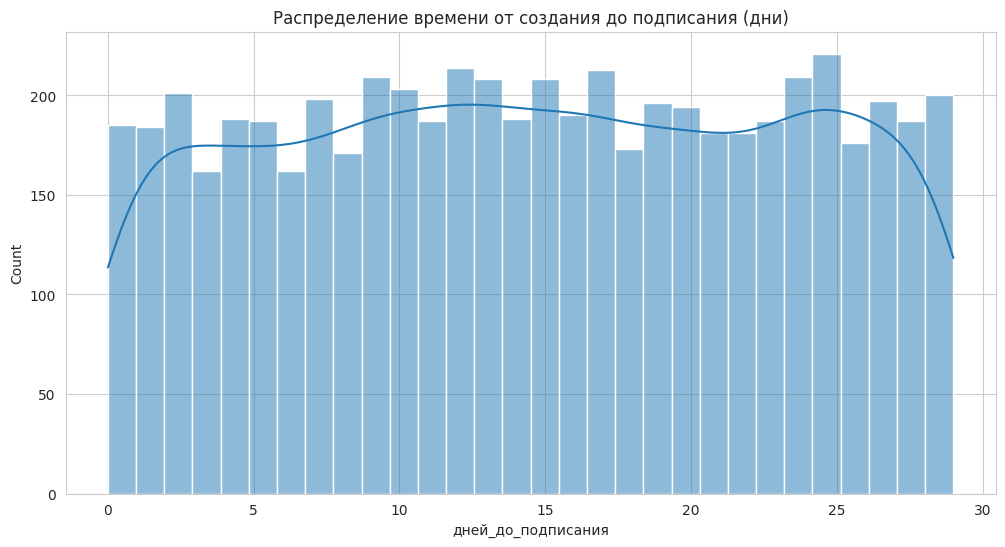

In [49]:
signed = contracts[contracts['статус']!='Черновик'].copy()
signed['дней_до_подписания'] = (signed['дата_подписания'] - signed['дата_создания']).dt.days
sns.histplot(signed['дней_до_подписания'], bins=30, kde=True)
plt.title('Распределение времени от создания до подписания (дни)')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


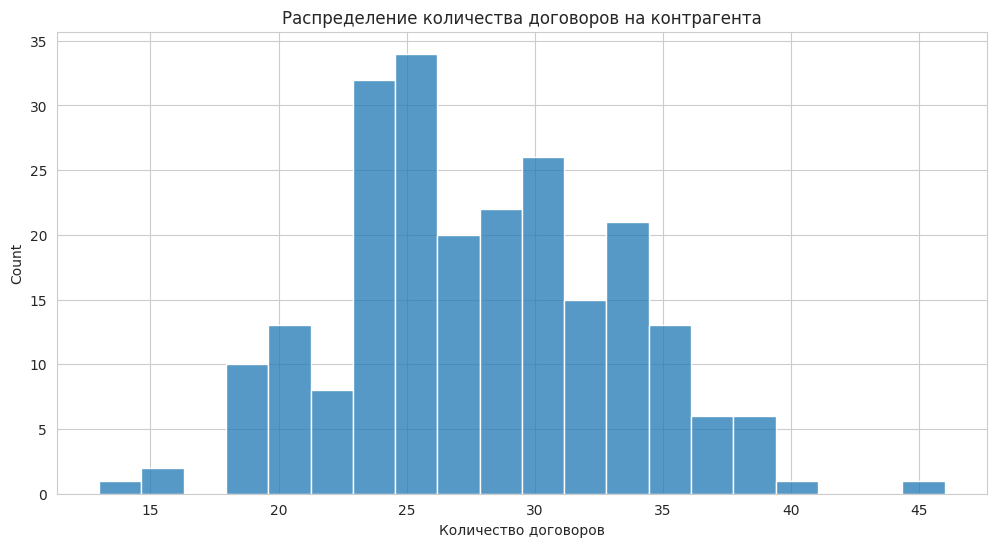

In [50]:
contracts_per_counterparty = contracts['id_контрагента'].value_counts()
sns.histplot(contracts_per_counterparty, bins=20, kde=False)
plt.title('Распределение количества договоров на контрагента')
plt.xlabel('Количество договоров')
plt.show()

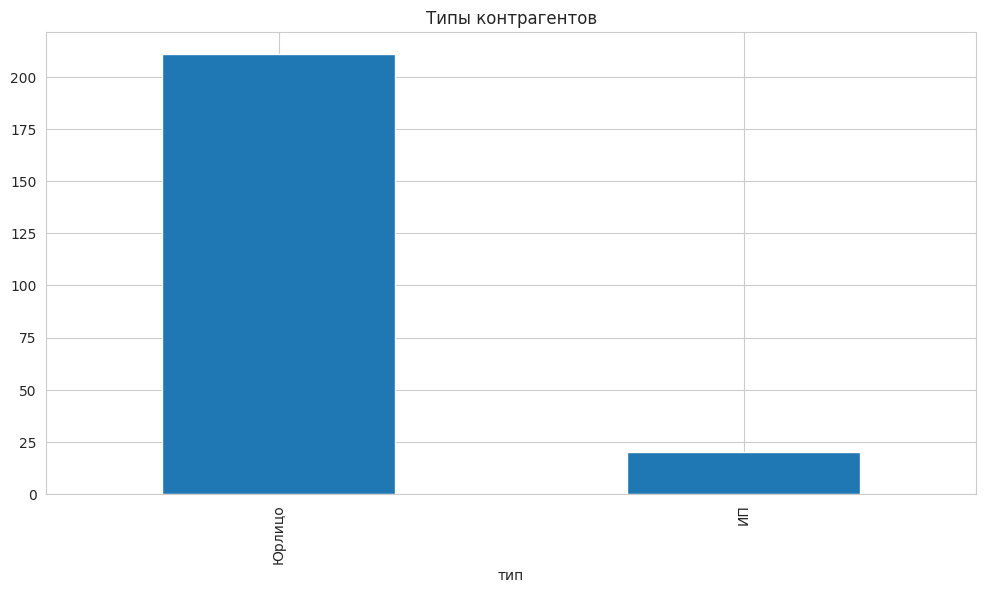

In [51]:
counterparties['тип'].value_counts().plot(kind='bar', title='Типы контрагентов')
plt.show()

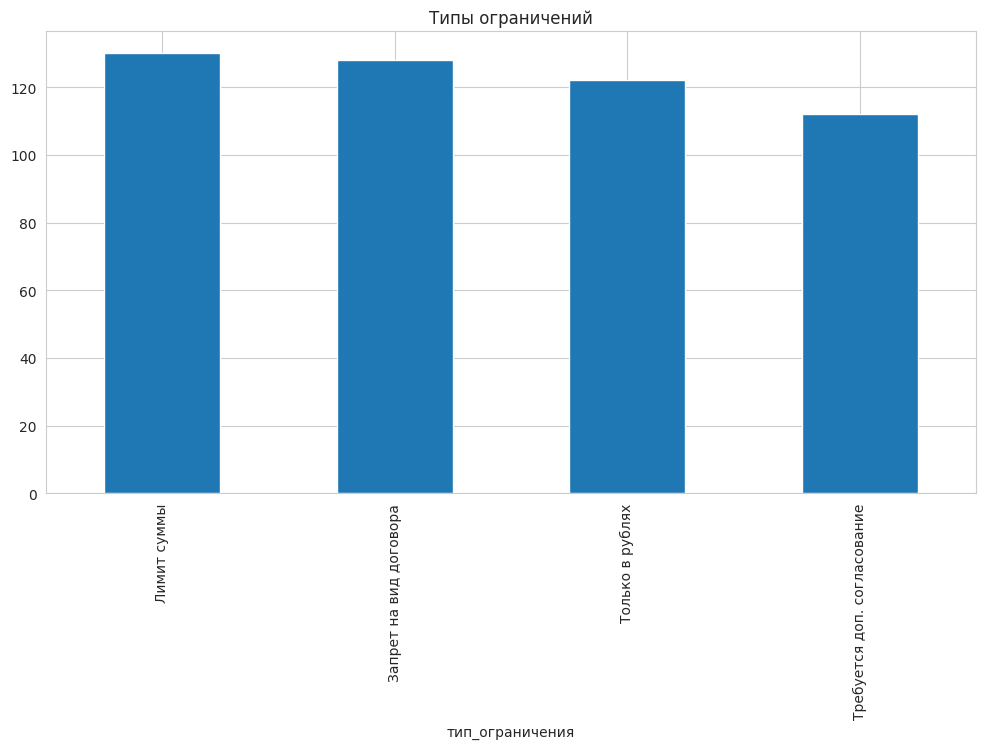

In [52]:
restrictions['тип_ограничения'].value_counts().plot(kind='bar', title='Типы ограничений')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


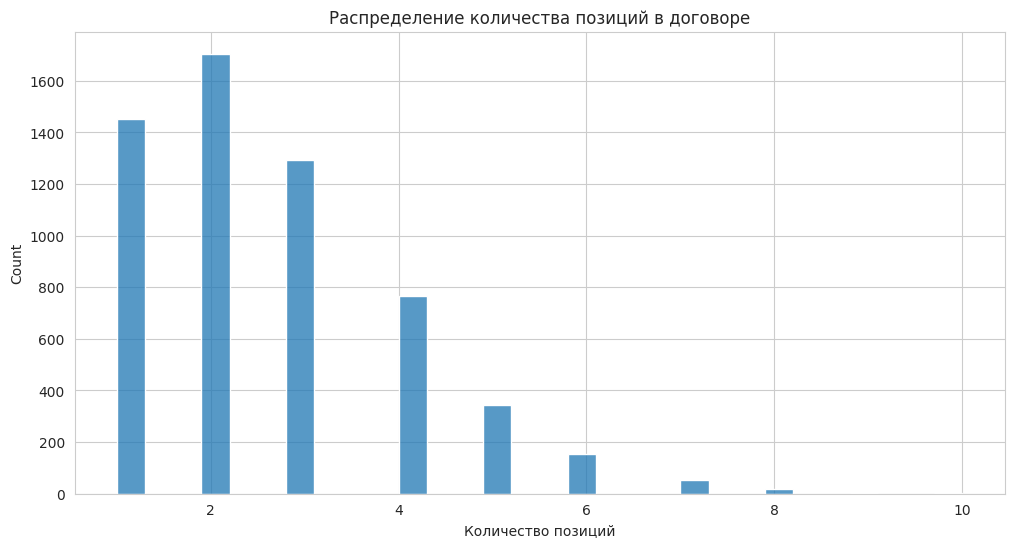

Среднее число позиций: 2.6


In [53]:
items_per_contract = items.groupby('id_договора').size()
sns.histplot(items_per_contract, bins=30, kde=False)
plt.title('Распределение количества позиций в договоре')
plt.xlabel('Количество позиций')
plt.show()
print(f"Среднее число позиций: {items_per_contract.mean():.1f}")

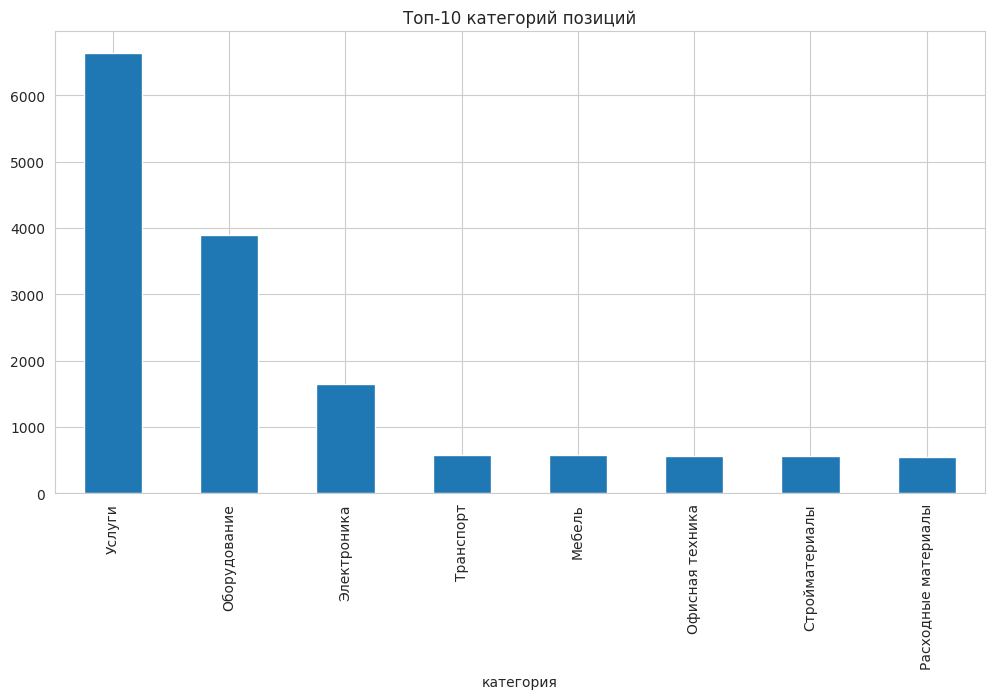

In [54]:
items['категория'].value_counts().head(10).plot(kind='bar', title='Топ-10 категорий позиций')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


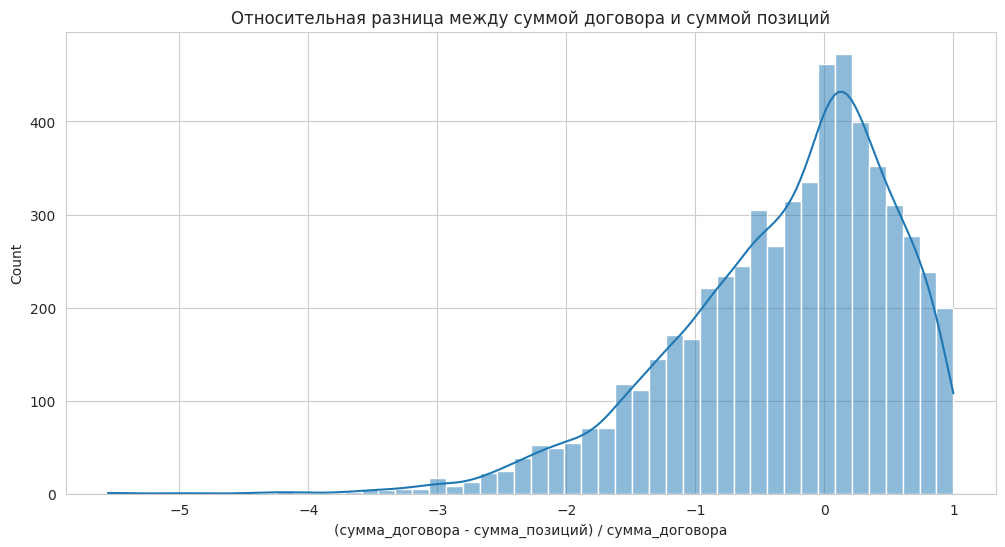

In [55]:
item_sum = items.groupby('id_договора')['сумма_в_рублях'].sum().reset_index()
item_sum.columns = ['id_договора', 'сумма_позиций']
merged = pd.merge(contracts[['id_договора', 'сумма_в_рублях']], item_sum, on='id_договора')
merged['разница'] = merged['сумма_в_рублях'] - merged['сумма_позиций']
merged['разница_отн'] = merged['разница'] / merged['сумма_в_рублях']
sns.histplot(merged['разница_отн'], bins=50, kde=True)
plt.title('Относительная разница между суммой договора и суммой позиций')
plt.xlabel('(сумма_договора - сумма_позиций) / сумма_договора')
plt.show()

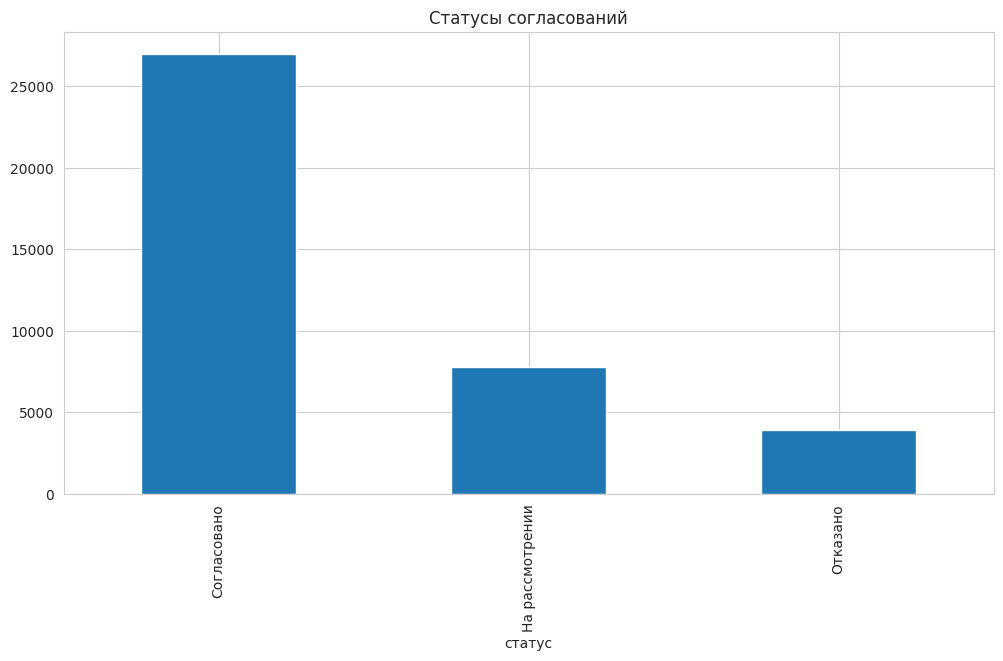

In [56]:
approvals['статус'].value_counts().plot(kind='bar', title='Статусы согласований')
plt.show()

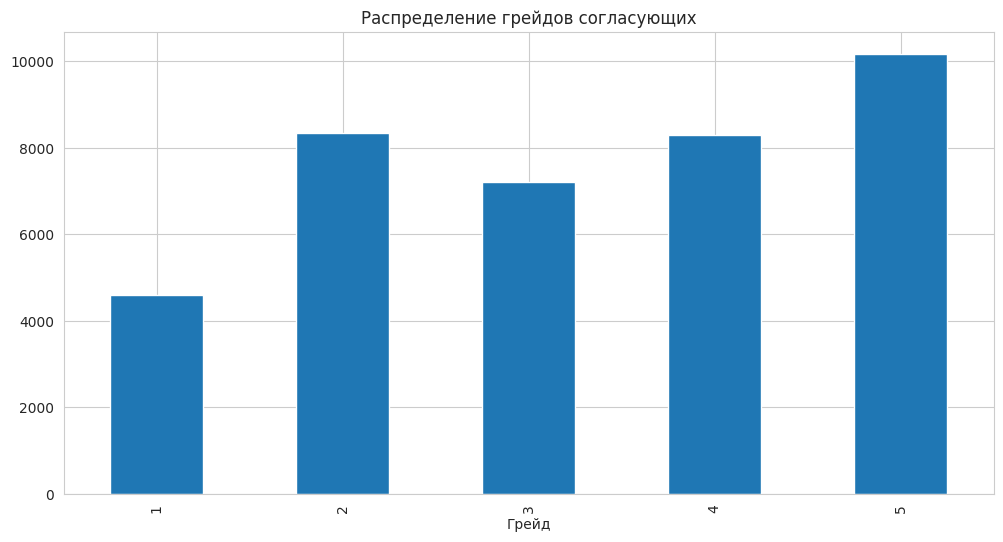

In [57]:
approvals['грейд'].value_counts().sort_index().plot(kind='bar', title='Распределение грейдов согласующих')
plt.xlabel('Грейд')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


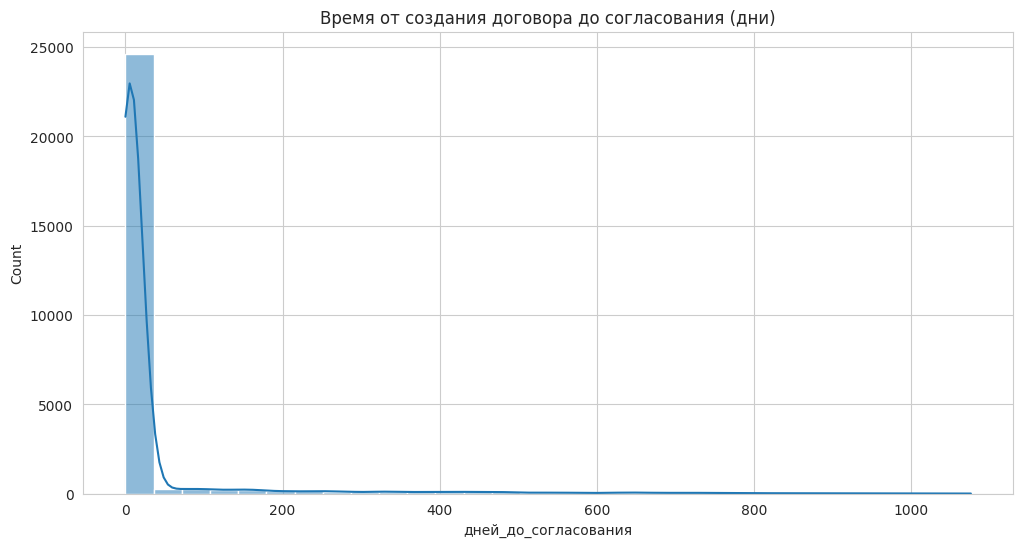

In [58]:
appr_ok = approvals[approvals['статус']=='Согласовано'].copy()
appr_ok = appr_ok.merge(contracts[['id_договора', 'дата_создания', 'дата_подписания']], on='id_договора')
appr_ok['дней_до_согласования'] = (appr_ok['дата_согласования'] - appr_ok['дата_создания']).dt.days
sns.histplot(appr_ok['дней_до_согласования'], bins=30, kde=True)
plt.title('Время от создания договора до согласования (дни)')
plt.show()

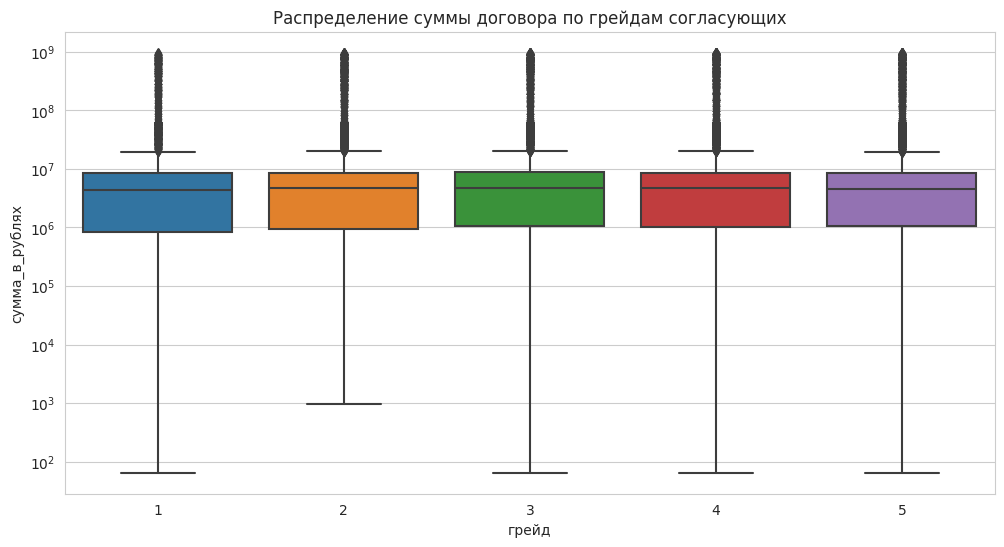

In [59]:
merged_approvals = approvals.merge(contracts[['id_договора', 'сумма_в_рублях']], on='id_договора')
sns.boxplot(x='грейд', y='сумма_в_рублях', data=merged_approvals)
plt.yscale('log')
plt.title('Распределение суммы договора по грейдам согласующих')
plt.show()

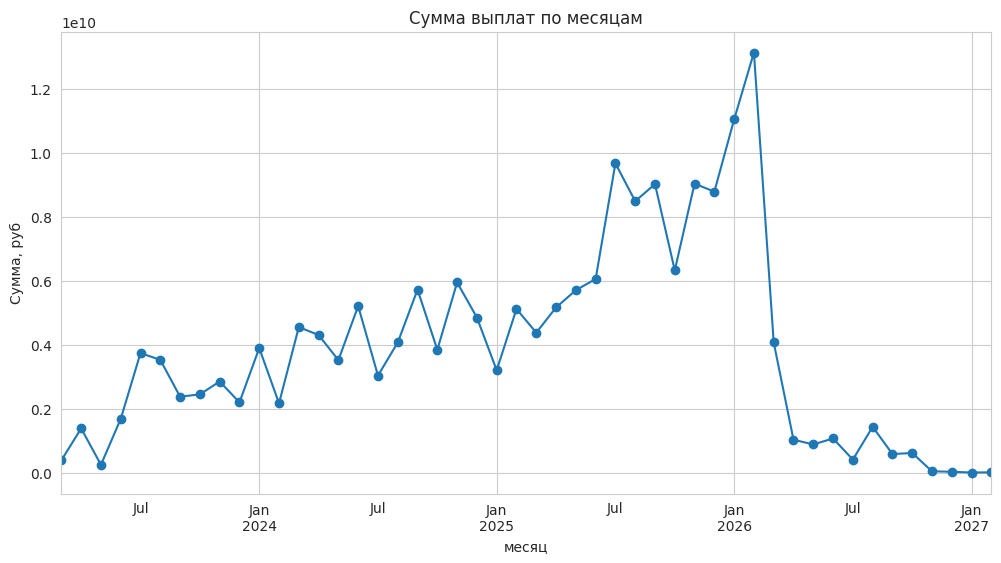

In [60]:
payments['месяц'] = payments['дата_выплаты'].dt.to_period('M')
monthly_payments = payments.groupby('месяц')['сумма_в_рублях'].sum()
monthly_payments.plot(kind='line', marker='o', title='Сумма выплат по месяцам')
plt.ylabel('Сумма, руб')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


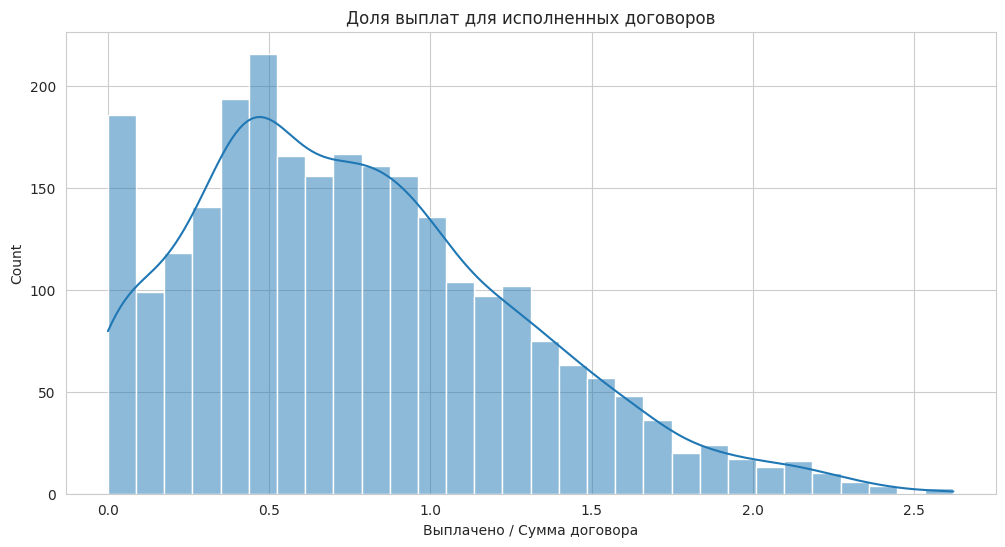

In [61]:
payment_sum = payments.groupby('id_договора')['сумма_в_рублях'].sum().reset_index()
payment_sum.columns = ['id_договора', 'выплачено']
merged_pay = pd.merge(contracts[['id_договора', 'сумма_в_рублях', 'статус']], payment_sum, on='id_договора', how='left')
merged_pay['выплачено'] = merged_pay['выплачено'].fillna(0)
merged_pay['доля_выплат'] = merged_pay['выплачено'] / merged_pay['сумма_в_рублях']
sns.histplot(merged_pay[merged_pay['статус']=='Исполнен']['доля_выплат'], bins=30, kde=True)
plt.title('Доля выплат для исполненных договоров')
plt.xlabel('Выплачено / Сумма договора')
plt.show()

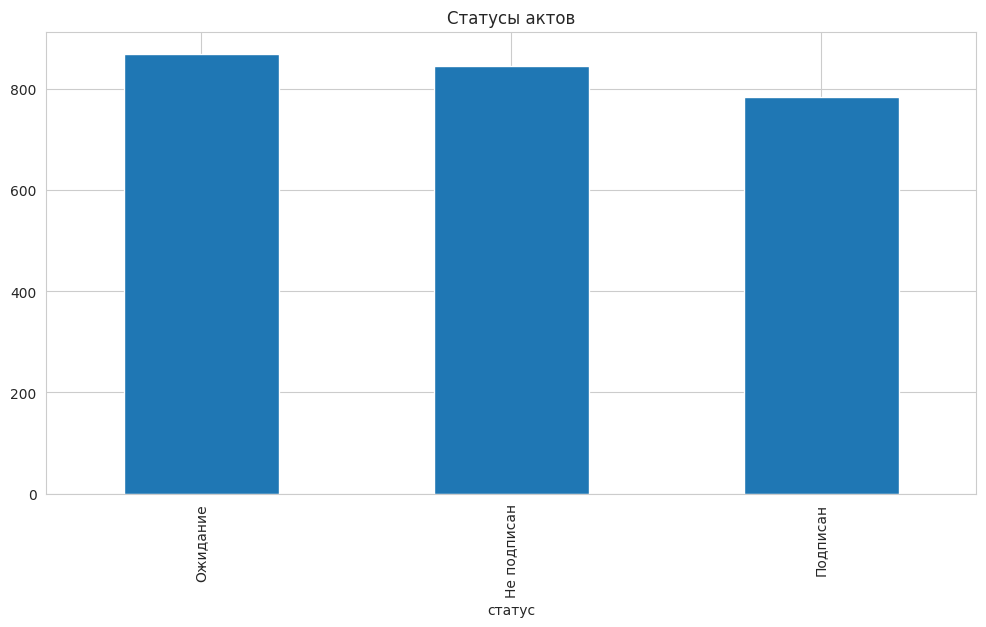

In [62]:
acts['статус'].value_counts().plot(kind='bar', title='Статусы актов')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


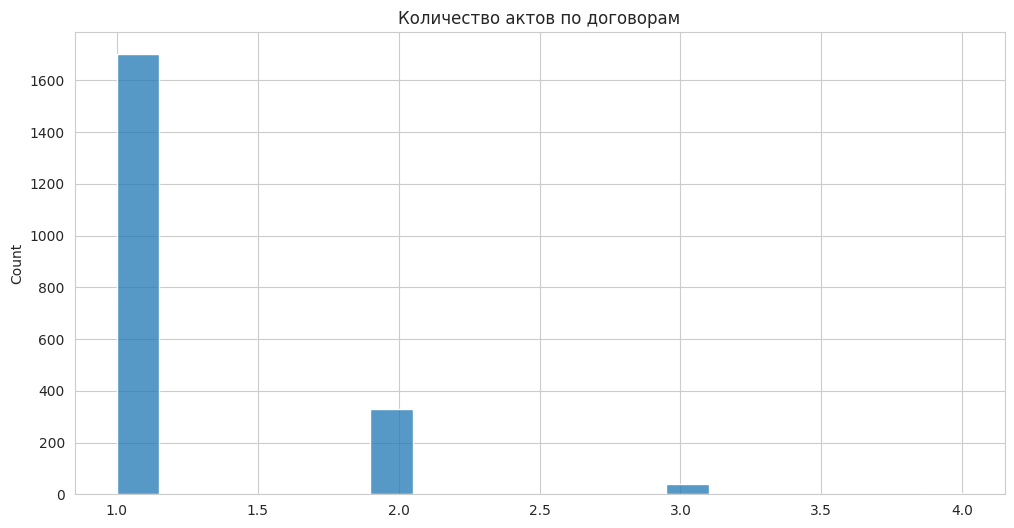

In [63]:
acts_per_contract = acts.groupby('id_договора').size()
sns.histplot(acts_per_contract, bins=20, kde=False)
plt.title('Количество актов по договорам')
plt.show()

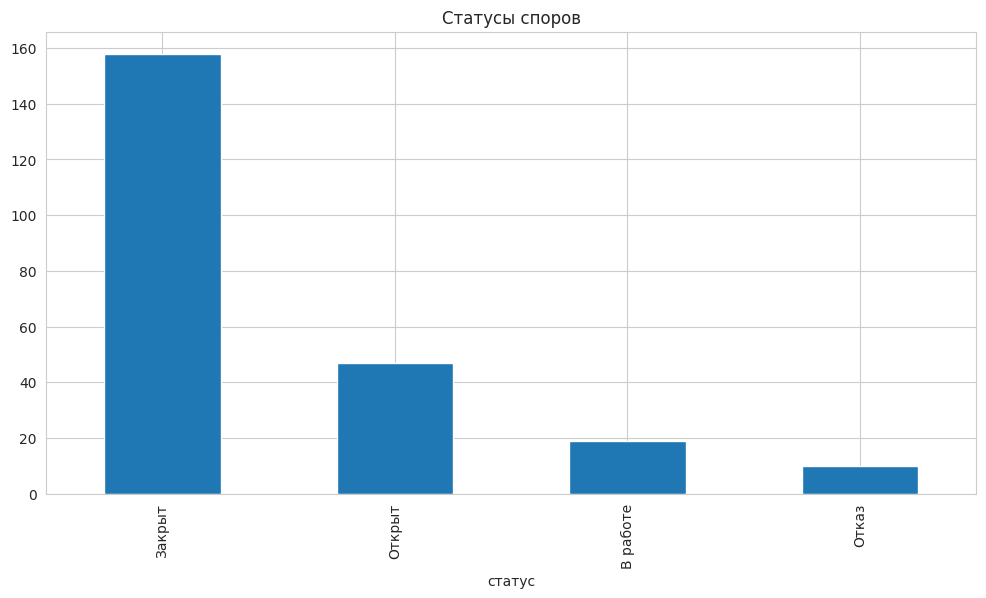

In [64]:
disputes['статус'].value_counts().plot(kind='bar', title='Статусы споров')
plt.show()

Реальные нарушения ограничений: 396

=== Длина комментариев в договорах ===
Все договоры: средняя длина = 23.3 символов
С нарушениями (n=396): средняя длина = 21.2
Без нарушений: средняя длина = 23.4


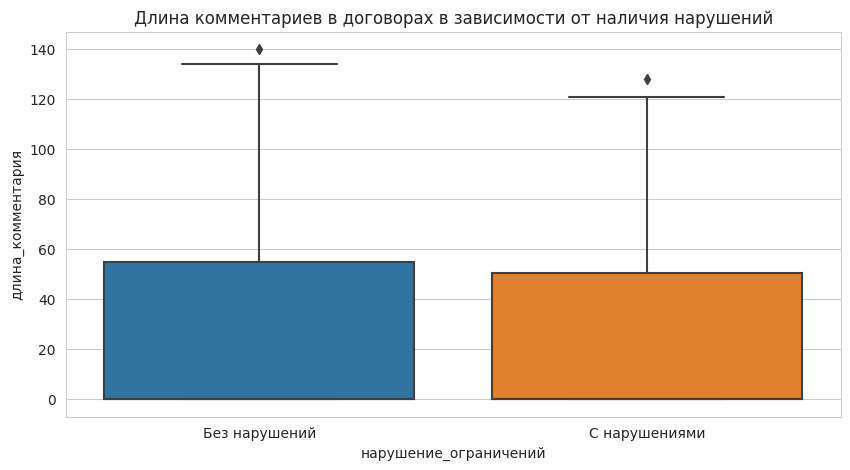


=== Длина комментариев в согласованиях ===
Для договоров с нарушениями: средняя длина = 29.9
Для договоров без нарушений: средняя длина = 29.0


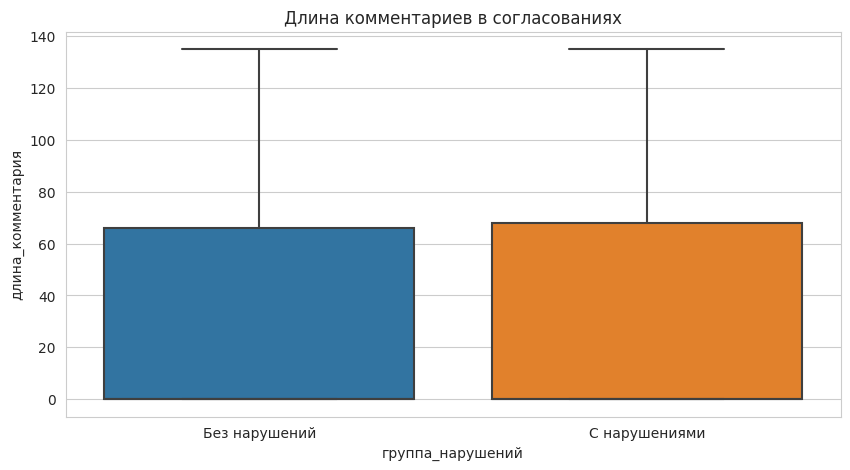


=== Длина всех комментариев в согласованиях ===
Для договоров с нарушениями: средняя длина = 71517.0
Для договоров без нарушений: средняя длина = 1049027.0


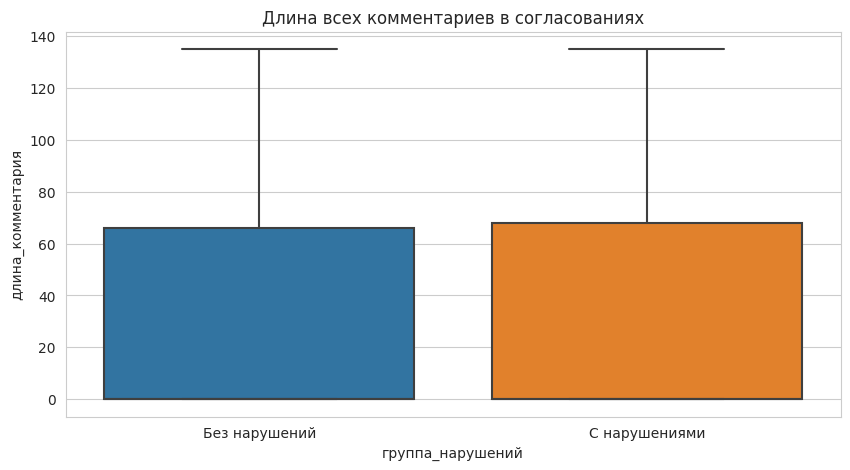

In [ ]:

contracts['дата_подписания'] = pd.to_datetime(contracts['дата_подписания'])
contracts['дата_создания'] = pd.to_datetime(contracts['дата_создания'])
restrictions['дата_начала'] = pd.to_datetime(restrictions['дата_начала'])
restrictions['дата_окончания'] = pd.to_datetime(restrictions['дата_окончания'])

def check_violation(row):
    cid = row['id_контрагента']
    contract_date = row['дата_подписания'] if pd.notna(row['дата_подписания']) else row['дата_создания']
    active = restrictions[
        (restrictions['id_контрагента'] == cid) &
        (restrictions['дата_начала'] <= contract_date) &
        (restrictions['дата_окончания'] >= contract_date) &
        (restrictions['активно'] == True)
    ]
    
    if active.empty:
        return False
    
    for _, r in active.iterrows():
        rtype = r['тип_ограничения']
        rval = r['значение']
        if rtype == 'Лимит суммы' and rval is not None:
            if row['сумма'] > rval:
                return True
        elif rtype == 'Только в рублях':
            if row['валюта'] != 'RUB':
                return True
    return False

contracts['нарушение_ограничений'] = contracts.apply(check_violation, axis=1)

print("Реальные нарушения ограничений:", contracts['нарушение_ограничений'].sum())
contracts_analysis = contracts.copy()

def comment_len(txt):
    return len(str(txt)) if pd.notna(txt) else 0

contracts_analysis['длина_комментария'] = contracts_analysis['комментарии'].apply(comment_len)
viol_mean = contracts_analysis.loc[contracts_analysis['нарушение_ограничений'], 'длина_комментария'].mean()
nonviol_mean = contracts_analysis.loc[~contracts_analysis['нарушение_ограничений'], 'длина_комментария'].mean()
overall_mean = contracts_analysis['длина_комментария'].mean()

print("\n=== Длина комментариев в договорах ===")
print(f"Все договоры: средняя длина = {overall_mean:.1f} символов")
print(f"С нарушениями (n={contracts_analysis['нарушение_ограничений'].sum()}): средняя длина = {viol_mean:.1f}")
print(f"Без нарушений: средняя длина = {nonviol_mean:.1f}")

plt.figure(figsize=(10,5))
sns.boxplot(x='нарушение_ограничений', y='длина_комментария', data=contracts_analysis)
plt.title('Длина комментариев в договорах в зависимости от наличия нарушений')
plt.xticks([0,1], ['Без нарушений', 'С нарушениями'])
plt.show()

viol_ids = contracts_analysis.loc[contracts_analysis['нарушение_ограничений'], 'id_договора'].tolist()
approvals['длина_комментария'] = approvals['комментарий'].apply(comment_len)
approvals['группа_нарушений'] = approvals['id_договора'].isin(viol_ids).map({True: 'С нарушениями', False: 'Без нарушений'})
viol_approx = approvals.loc[approvals['группа_нарушений'] == 'С нарушениями', 'длина_комментария'].mean()
nonviol_approx = approvals.loc[approvals['группа_нарушений'] == 'Без нарушений', 'длина_комментария'].mean()
print("\n=== Длина комментариев в согласованиях ===")
print(f"Для договоров с нарушениями: средняя длина = {viol_approx:.1f}")
print(f"Для договоров без нарушений: средняя длина = {nonviol_approx:.1f}")
plt.figure(figsize=(10,5))
sns.boxplot(x='группа_нарушений', y='длина_комментария', data=approvals)
plt.title('Длина комментариев в согласованиях')
plt.show()


viol_ids = contracts_analysis.loc[contracts_analysis['нарушение_ограничений'], 'id_договора'].tolist()
approvals['длина_комментария'] = approvals['комментарий'].apply(comment_len)
approvals['группа_нарушений'] = approvals['id_договора'].isin(viol_ids).map({True: 'С нарушениями', False: 'Без нарушений'})
viol_approx = approvals.loc[approvals['группа_нарушений'] == 'С нарушениями', 'длина_комментария'].sum()
nonviol_approx = approvals.loc[approvals['группа_нарушений'] == 'Без нарушений', 'длина_комментария'].sum()
print("\n=== Длина всех комментариев в согласованиях ===")
print(f"Для договоров с нарушениями: средняя длина = {viol_approx:.1f}")
print(f"Для договоров без нарушений: средняя длина = {nonviol_approx:.1f}")
plt.figure(figsize=(10,5))
sns.boxplot(x='группа_нарушений', y='длина_комментария', data=approvals)
plt.title('Длина всех комментариев в согласованиях')
plt.show()

Выводы по реальным данным:

Выводы на основании реальных данных - в отличие от синтетики качество данных в ряде показателей не является удовлетворительным, 
уточнение ряда булевых признаков при их расхождении, точная классификация ролей и обоснованность алгоритмически выевляемых расхождений требует анализа введённого людьми текста.

Классификация ряда применяющихся типов не очевидна, часто имеются синонимичные по общему смыслу типы с разными классами в системе. Консультация с доступными экспертами ситуацию не прояснил - типы сложились в ходе особенностей практического применения. 

В ряде процедур отсутствует однозначная связь между конкретной заявкой и итоговым документом, что требует анализа текста 1-4 заявок.

Часто в разных системах для обозначения одного и того же используются разные варинты написания, что усложняет сверку алгоритмами, однако при помощи алгоритмических методов можно значительно сократить колличество анализируемых строк (в конкретном примере ппереписанных в процессе условий получилось снизить колличество случаев с тысяч до около двух сотен)